# Experiment 3: Regression Analysis using Linear and Regularized Models

Predicting `Loan Amount Request (USD)` using Linear, Ridge, Lasso, and Elastic Net regression on the Kaggle *Predict Loan Amount Data* dataset.

Place `loan_amount_data.csv` in a `data/` folder next to this notebook before running.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

## 1. Load Dataset

In [2]:
df = pd.read_csv("data/loan_amount_data.csv")
print("Raw shape:", df.shape)
df.head()

Raw shape: (20000, 23)


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Dependents,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price
0,C-26247,Tandra Olszewski,F,47,3472.69,Low,Commercial associate,Managers,Semi-Urban,137088.98,...,2.0,799.14,0,Unpossessed,843,3472.69,2,Urban,1,236644.5
1,C-35067,Jeannette Cha,F,57,1184.84,Low,Working,Sales staff,Rural,104771.59,...,2.0,833.31,0,Unpossessed,22,1184.84,1,Rural,1,142357.3
2,C-34590,Keva Godfrey,F,52,1266.27,Low,Working,NaN,Semi-Urban,176684.91,...,3.0,627.44,0,Unpossessed,1,1266.27,1,Urban,1,300991.24
3,C-16668,Elva Sackett,M,65,1369.72,High,Pensioner,NaN,Rural,97009.18,...,2.0,833.20,0,Inactive,730,1369.72,1,Semi-Urban,0,125612.1
4,C-12196,Sade Constable,F,60,1939.23,High,Pensioner,NaN,Urban,109980.00,...,NaN,NaN,0,NaN,356,1939.23,4,Semi-Urban,1,180908.0


## 2. Preprocessing

In [3]:
# Disguised missing values marked as "?"
df["Property Price"] = pd.to_numeric(df["Property Price"].replace("?", np.nan))
df["Co-Applicant"] = pd.to_numeric(df["Co-Applicant"].replace("?", np.nan))

# Drop identifier / free-text columns
df = df.drop(columns=["Customer ID", "Name", "Property ID"])

target_col = "Loan Amount Request (USD)"

cat_cols = ["Gender", "Income Stability", "Profession", "Type of Employment", "Location",
            "Expense Type 1", "Expense Type 2", "Has Active Credit Card", "Property Type",
            "Property Location"]
num_cols = ["Age", "Income (USD)", "Current Loan Expenses (USD)", "Dependents",
            "Credit Score", "No. of Defaults", "Property Age", "Co-Applicant", "Property Price"]

print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values:
Gender                           31
Income (USD)                    750
Income Stability                813
Type of Employment             4689
Current Loan Expenses (USD)      83
Dependents                     1142
Credit Score                    743
Has Active Credit Card         1076
Property Age                    892
Property Location               160
Co-Applicant                     77
Property Price                  168
dtype: int64


In [4]:
for c in cat_cols:
    df[c] = df[c].astype(str).replace("nan", np.nan)
    df[c] = df[c].fillna(df[c].mode()[0])
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

X = df[cat_cols + num_cols]
y = df[target_col]
print("Final X shape:", X.shape)
y.describe()

Final X shape: (20000, 19)


count     20000.000000
mean      88859.076706
std       60007.333673
min        6185.480000
25%       40889.030000
50%       74565.990000
75%      120068.852500
max      576335.680000
Name: Loan Amount Request (USD), dtype: float64

## 3. Exploratory Data Analysis

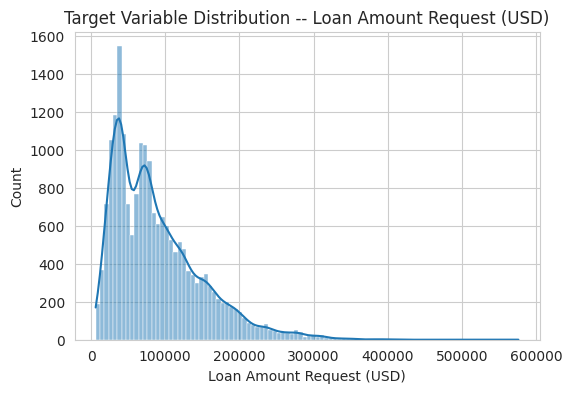

Target skewness: 1.278


In [5]:
plt.figure(figsize=(6,4))
sns.histplot(y, kde=True)
plt.title("Target Variable Distribution -- Loan Amount Request (USD)")
plt.show()
print("Target skewness:", round(y.skew(), 3))

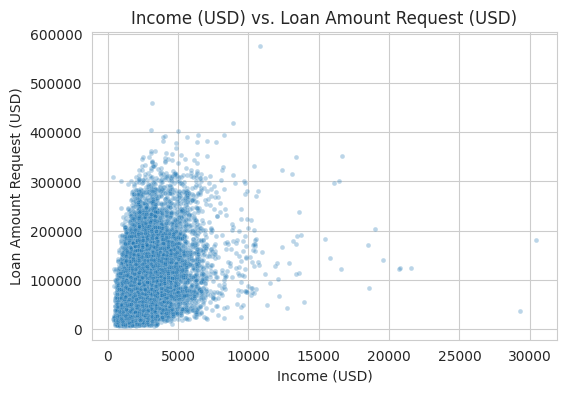

Income (USD) correlation with target: 0.364


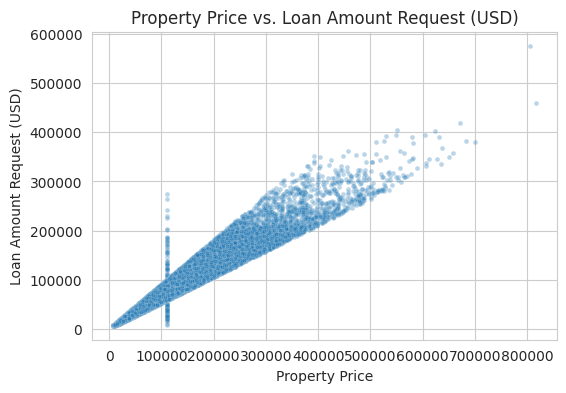

Property Price correlation with target: 0.961


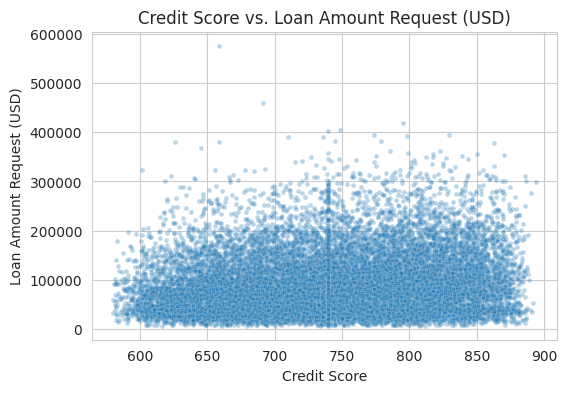

Credit Score correlation with target: 0.168


In [6]:
for feat in ["Income (USD)", "Property Price", "Credit Score"]:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[feat], y=y, alpha=0.3, s=12)
    plt.title(f"{feat} vs. Loan Amount Request (USD)")
    plt.show()
    print(feat, "correlation with target:", round(df[feat].corr(y), 3))

## 4. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", len(X_train), " Test:", len(X_test))

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
])

Train: 16000  Test: 4000


## 5. Baseline Linear Regression + CV / Test Helper Functions

In [8]:
def build_pipe(estimator):
    return Pipeline([("prep", preprocessor), ("model", estimator)])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_metrics(pipe, X, y):
    maes, mses, rmses, r2s = [], [], [], []
    for tr_idx, val_idx in kf.split(X):
        Xtr, Xval = X.iloc[tr_idx], X.iloc[val_idx]
        ytr, yval = y.iloc[tr_idx], y.iloc[val_idx]
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xval)
        maes.append(mean_absolute_error(yval, pred))
        mses.append(mean_squared_error(yval, pred))
        rmses.append(np.sqrt(mean_squared_error(yval, pred)))
        r2s.append(r2_score(yval, pred))
    return dict(MAE=np.mean(maes), MSE=np.mean(mses), RMSE=np.mean(rmses), R2=np.mean(r2s))

def test_metrics(pipe, X_train, y_train, X_test, y_test):
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0
    pred = pipe.predict(X_test)
    return dict(
        MAE=mean_absolute_error(y_test, pred),
        MSE=mean_squared_error(y_test, pred),
        RMSE=np.sqrt(mean_squared_error(y_test, pred)),
        R2=r2_score(y_test, pred),
        TrainingTime=train_time,
    ), pred

In [9]:
cv_results, test_results, predictions, fitted_pipes = {}, {}, {}, {}

lin_pipe = build_pipe(LinearRegression())
cv_results["Linear Regression"] = cv_metrics(lin_pipe, X_train, y_train)
test_results["Linear Regression"], predictions["Linear Regression"] = test_metrics(lin_pipe, X_train, y_train, X_test, y_test)
fitted_pipes["Linear Regression"] = lin_pipe
cv_results["Linear Regression"], test_results["Linear Regression"]

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


({'MAE': np.float64(11089.720632585368),
  'MSE': np.float64(250583447.48285526),
  'RMSE': np.float64(15828.557361531304),
  'R2': np.float64(0.9301914234034241)},
 {'MAE': 10902.285992607101,
  'MSE': 233186893.32577068,
  'RMSE': np.float64(15270.458189778416),
  'R2': 0.9355272846032554,
  'TrainingTime': 0.08161044120788574})

## 6/7. Ridge, Lasso, Elastic Net + GridSearchCV Hyperparameter Tuning

In [10]:
param_grids = {
    "Ridge Regression": (Ridge(random_state=42), {"model__alpha": [0.01, 0.1, 1, 10, 100]}),
    "Lasso Regression": (Lasso(random_state=42, max_iter=20000), {"model__alpha": [0.001, 0.01, 0.1, 1, 10]}),
    "Elastic Net Regression": (ElasticNet(random_state=42, max_iter=20000),
                                {"model__alpha": [0.01, 0.1, 1, 10], "model__l1_ratio": [0.2, 0.5, 0.8]}),
}

tuning_summary = {}
for name, (estimator, grid) in param_grids.items():
    pipe = build_pipe(estimator)
    gs = GridSearchCV(pipe, param_grid=grid, cv=kf, scoring="r2", n_jobs=-1)
    gs.fit(X_train, y_train)
    best_pipe = gs.best_estimator_
    tuning_summary[name] = {"best_params": gs.best_params_, "best_cv_r2": round(gs.best_score_, 4)}
    cv_results[name] = cv_metrics(best_pipe, X_train, y_train)
    test_results[name], predictions[name] = test_metrics(best_pipe, X_train, y_train, X_test, y_test)
    fitted_pipes[name] = best_pipe

tuning_summary

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


...

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


{'Ridge Regression': {'best_params': {'model__alpha': 10},
  'best_cv_r2': np.float64(0.9302)},
 'Lasso Regression': {'best_params': {'model__alpha': 10},
  'best_cv_r2': np.float64(0.9303)},
 'Elastic Net Regression': {'best_params': {'model__alpha': 0.01,
   'model__l1_ratio': 0.8},
  'best_cv_r2': np.float64(0.9302)}}

## 8. Performance Tables

In [11]:
pd.DataFrame(cv_results).T

,MAE,MSE,RMSE,R2
Linear Regression,11089.720633,2.505834e+08,15828.557362,0.930191
Ridge Regression,11085.382860,2.504725e+08,15825.076193,0.930222
Lasso Regression,11077.054325,2.503616e+08,15821.614116,0.930253
Elastic Net Regression,11083.350747,2.504444e+08,15824.206927,0.930229


In [12]:
pd.DataFrame(test_results).T

,MAE,MSE,RMSE,R2,TrainingTime
Linear Regression,10902.285993,2.331869e+08,15270.458190,0.935527,0.081610
Ridge Regression,10900.511348,2.331071e+08,15267.844679,0.935549,0.051644
Lasso Regression,10890.305524,2.328007e+08,15257.808429,0.935634,0.097853
Elastic Net Regression,10899.711688,2.330546e+08,15266.126581,0.935564,0.215602


## 9. Predicted vs. Actual and Residual Plots (Best Model)

In [13]:
best_model_name = min(test_results, key=lambda k: test_results[k]["RMSE"])
print("Best model by test RMSE:", best_model_name)
best_pred = predictions[best_model_name]

Best model by test RMSE: Lasso Regression


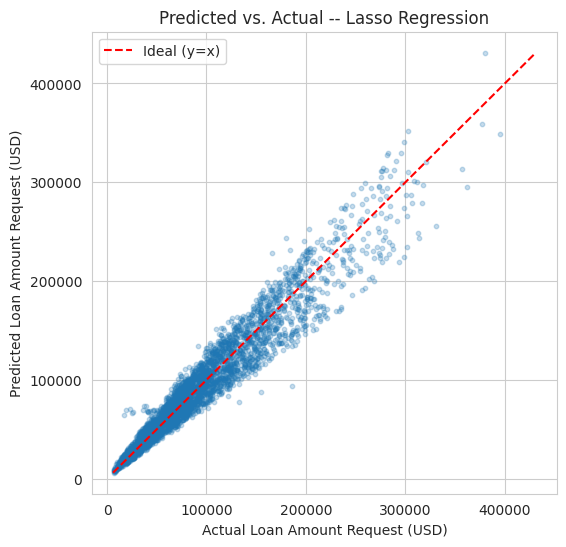

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, best_pred, alpha=0.25, s=10)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, "r--", label="Ideal (y=x)")
plt.xlabel("Actual Loan Amount Request (USD)")
plt.ylabel("Predicted Loan Amount Request (USD)")
plt.title(f"Predicted vs. Actual -- {best_model_name}")
plt.legend()
plt.show()

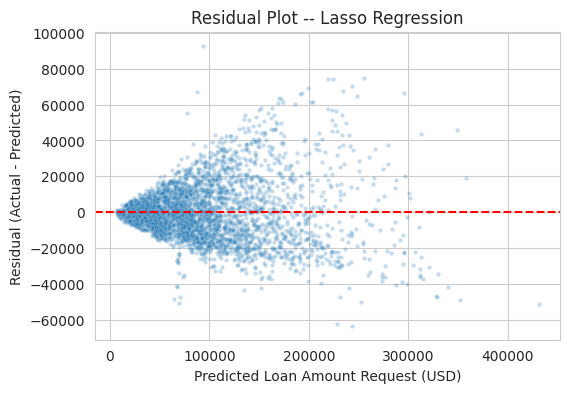

Residual mean: -309.105  std: 15254.677


In [15]:
residuals = y_test.values - best_pred
plt.figure(figsize=(6,4))
sns.scatterplot(x=best_pred, y=residuals, alpha=0.25, s=10)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Loan Amount Request (USD)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot -- {best_model_name}")
plt.show()
print("Residual mean:", round(residuals.mean(),3), " std:", round(residuals.std(),3))

## 10. Training Error vs. Validation Error (Learning Curve)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


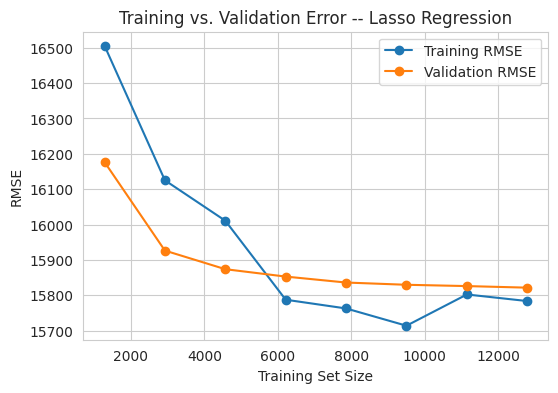

In [16]:
train_sizes, train_scores, val_scores = learning_curve(
    fitted_pipes[best_model_name], X_train, y_train, cv=kf,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42
)
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_rmse, "o-", label="Training RMSE")
plt.plot(train_sizes, val_rmse, "o-", label="Validation RMSE")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title(f"Training vs. Validation Error -- {best_model_name}")
plt.legend()
plt.show()

## 11. Coefficient Comparison Across Models

In [17]:
feature_names = fitted_pipes["Linear Regression"].named_steps["prep"].get_feature_names_out()
coef_table = pd.DataFrame({"Feature": feature_names})
for name in ["Linear Regression", "Ridge Regression", "Lasso Regression", "Elastic Net Regression"]:
    coef_table[name] = fitted_pipes[name].named_steps["model"].coef_

coef_table_sorted = coef_table.reindex(coef_table["Linear Regression"].abs().sort_values(ascending=False).index)
top_feats = coef_table_sorted.head(8)
top_feats

,Feature,Linear Regression,Ridge Regression,Lasso Regression,Elastic Net Regression
8,num__Property Price,51582.852976,51521.837397,51592.672849,51385.982093
2,num__Current Loan Expenses (USD),7726.654305,7765.237826,7720.968710,7849.491781
15,cat__Profession_Unemployed,3780.172626,681.123004,0.000000,258.361309
10,cat__Income Stability_Low,-3631.363723,-3030.828581,-1772.414832,-2316.415652
31,cat__Type of Employment_Secretaries,-3597.258210,-3003.199830,-993.283311,-2256.689099
18,cat__Type of Employment_Cooking staff,-3460.010649,-3095.057998,-2081.949504,-2640.071822
29,cat__Type of Employment_Realty agents,-3117.049417,-2450.692720,-0.000000,-1688.451350
23,cat__Type of Employment_IT staff,-2956.413235,-2235.514536,-0.000000,-1462.231124


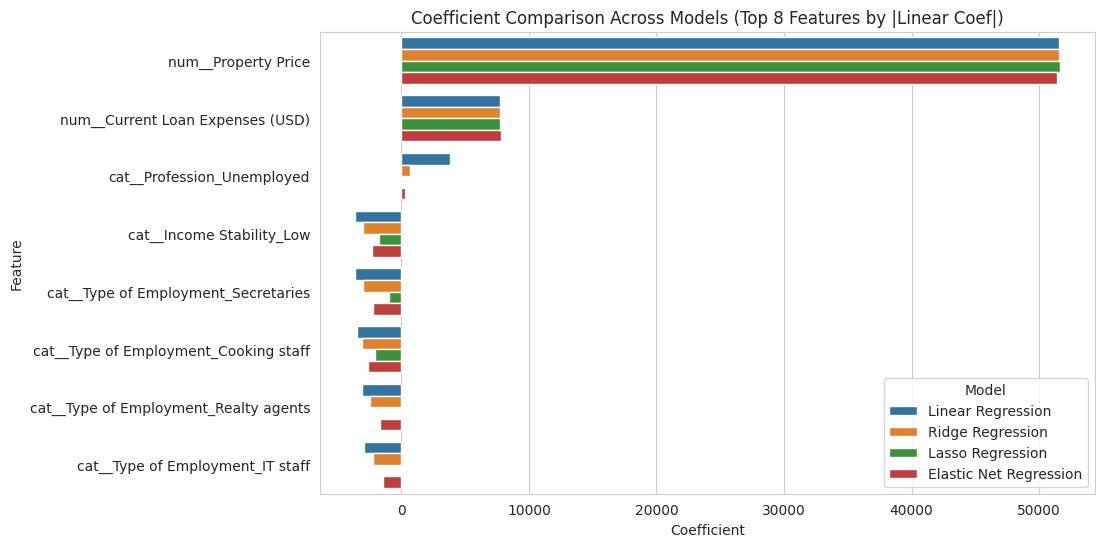

In [18]:
melted = top_feats.melt(id_vars="Feature", var_name="Model", value_name="Coefficient")
plt.figure(figsize=(10,6))
sns.barplot(data=melted, x="Coefficient", y="Feature", hue="Model")
plt.title("Coefficient Comparison Across Models (Top 8 Features by |Linear Coef|)")
plt.show()

## 12. Summary

See the accompanying report (`Experiment3.pdf`) for the full discussion of overfitting/underfitting and bias-variance analysis grounded in these results.